## 1. import libraries

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

read csv

In [130]:
df = pd.read_csv(r"C:\Users\HAZEL\Desktop\ML1_Capstone\ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [131]:
df.shape

(10000, 14)

In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [133]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


## 2. Exploratory data analysis

#### 2.0 . understanding our data 

In [134]:
df[["UDI","Product ID"]].head()

df["UDI"].nunique()

df["Product ID"].nunique()

10000

#### 2.1 . Missing values  

In [135]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

#### 2.2 . Outliers 


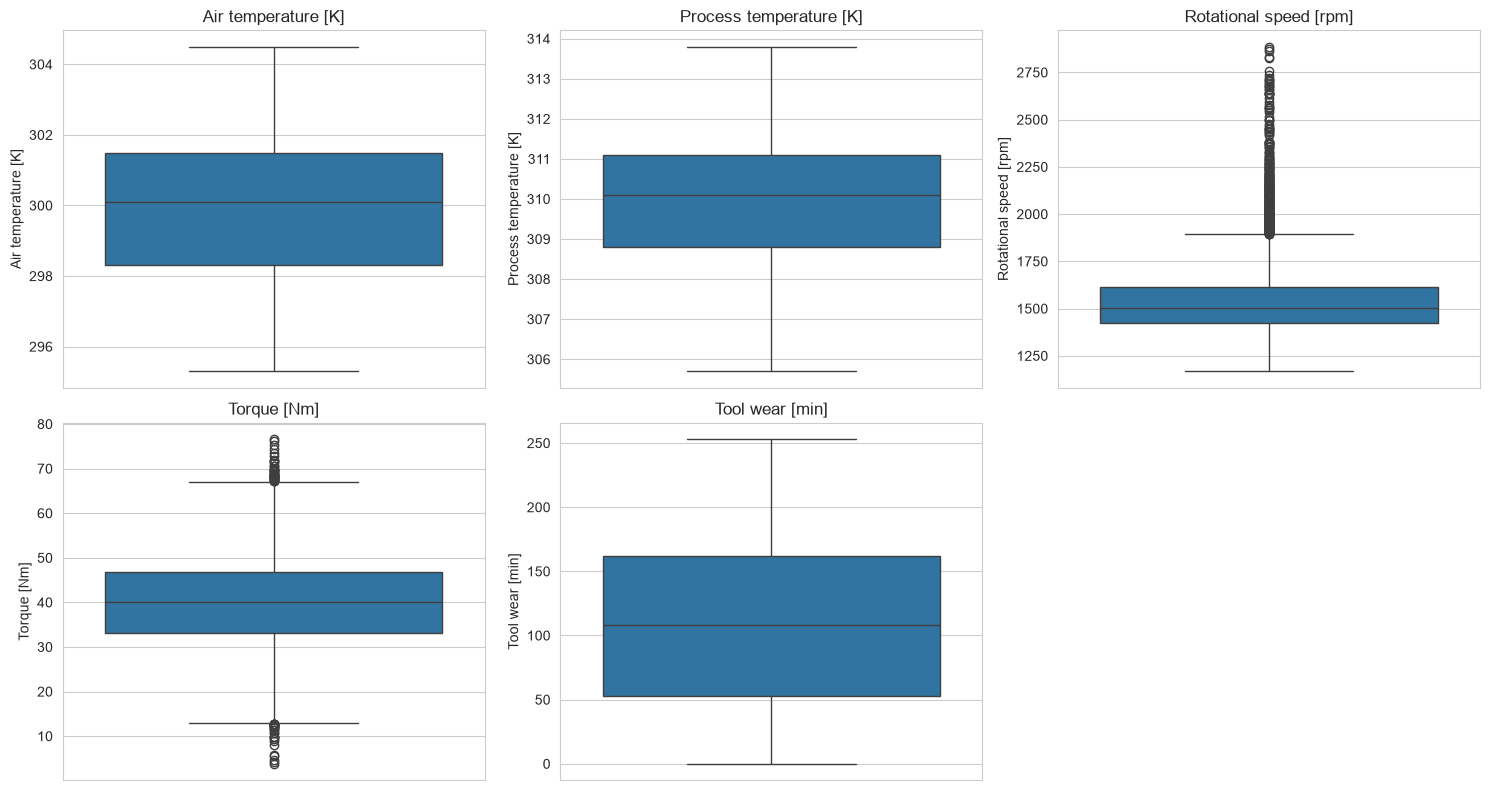

In [136]:
numerical_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### 2.3 . duplicate values 

In [137]:
df.duplicated().sum()

np.int64(0)

#### 2.4 Data Distribution


In [138]:
# Check unique values
df["Type"].unique()

# Count each category
df["Type"].value_counts()

# Percentage distribution
df["Type"].value_counts(normalize=True) * 100

Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64

In [139]:
df[["Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"]].head(20)
df[["TWF","HDF","PWF","OSF","RNF"]].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [140]:
# check the target column - clearly shows class imbalance
df["Machine failure"].value_counts()

df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

my dataset has a very high class imbalance

##### Univariate analysis

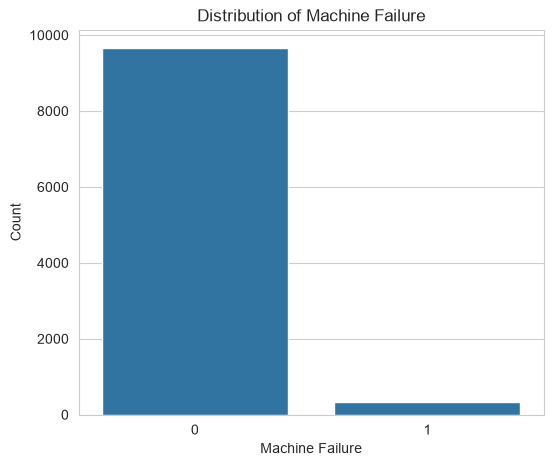

In [141]:
# analyse the target variable 
# to check whether the dataset is balanced 
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Distribution of Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

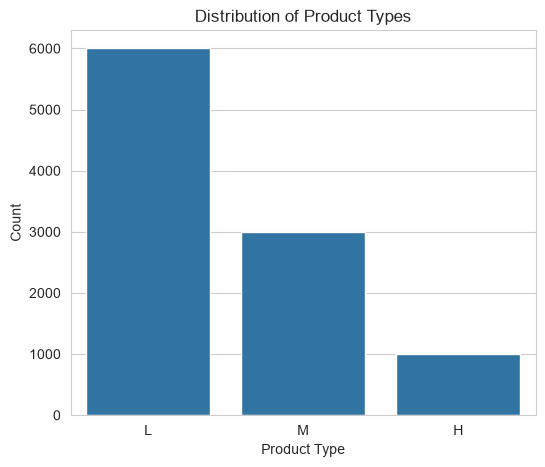

In [142]:
# check the didtribution of type 
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Type",
    order=df["Type"].value_counts().index
)

plt.title("Distribution of Product Types")
plt.xlabel("Product Type")
plt.ylabel("Count")

plt.show()

Bivariate Analysis

<Axes: xlabel='Type', ylabel='count'>

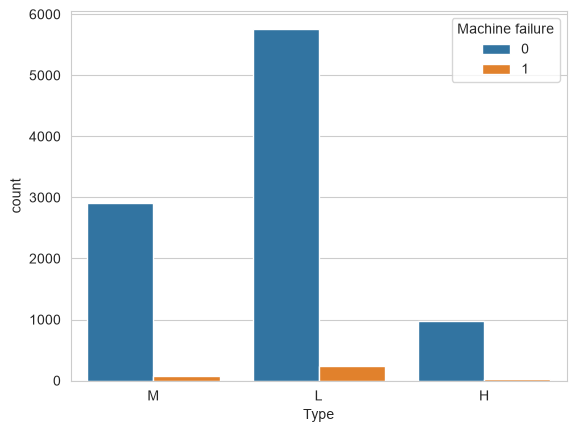

In [143]:
# type vs machine failure
sns.countplot(
    data=df,
    x="Type",
    hue="Machine failure"
)

is machine failure cause by product type?

L - highest number of failures

does that mean L products fail the most?

NO -  they have the higest count so it makes sense that they fail the most if they are the most products


In [144]:
failure_rate = (
    pd.crosstab(
        df["Type"],
        df["Machine failure"],
        normalize="index"
    )*100
)

failure_rate

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


The difference between product type is very low so its an unlikely a strong predictor for machine failuer

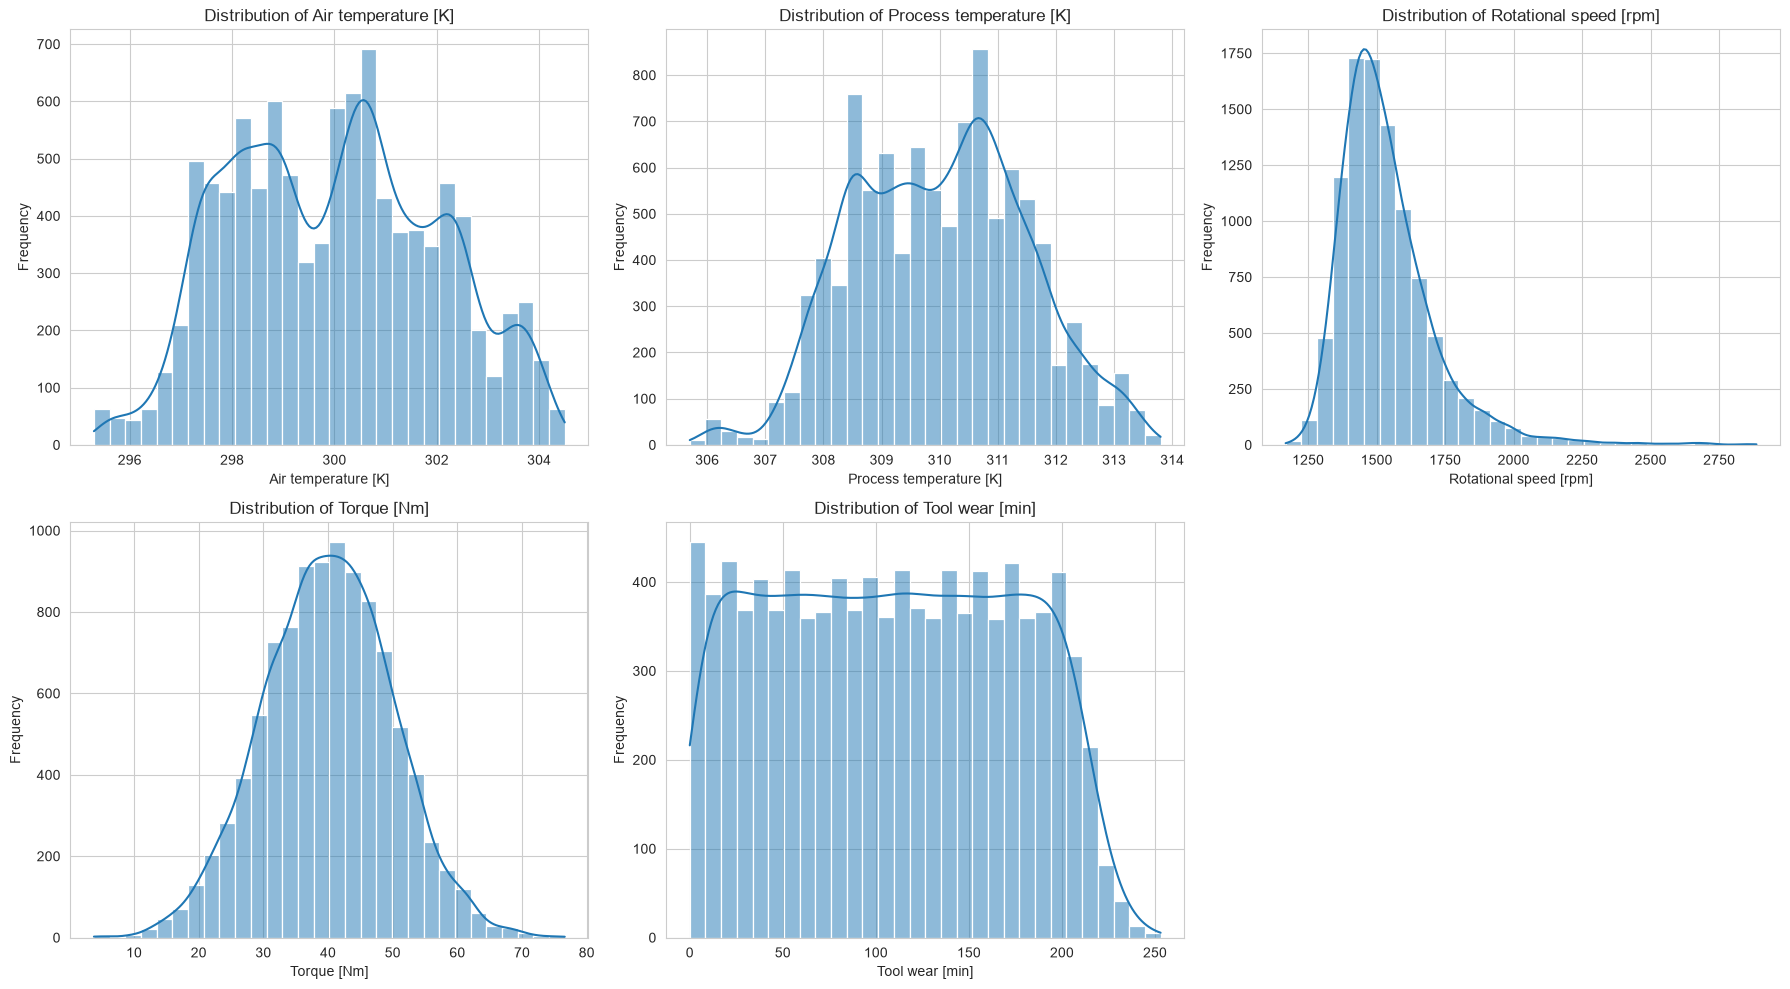

In [145]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns BEFORE feature engineering
numerical_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Distribution Plots
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

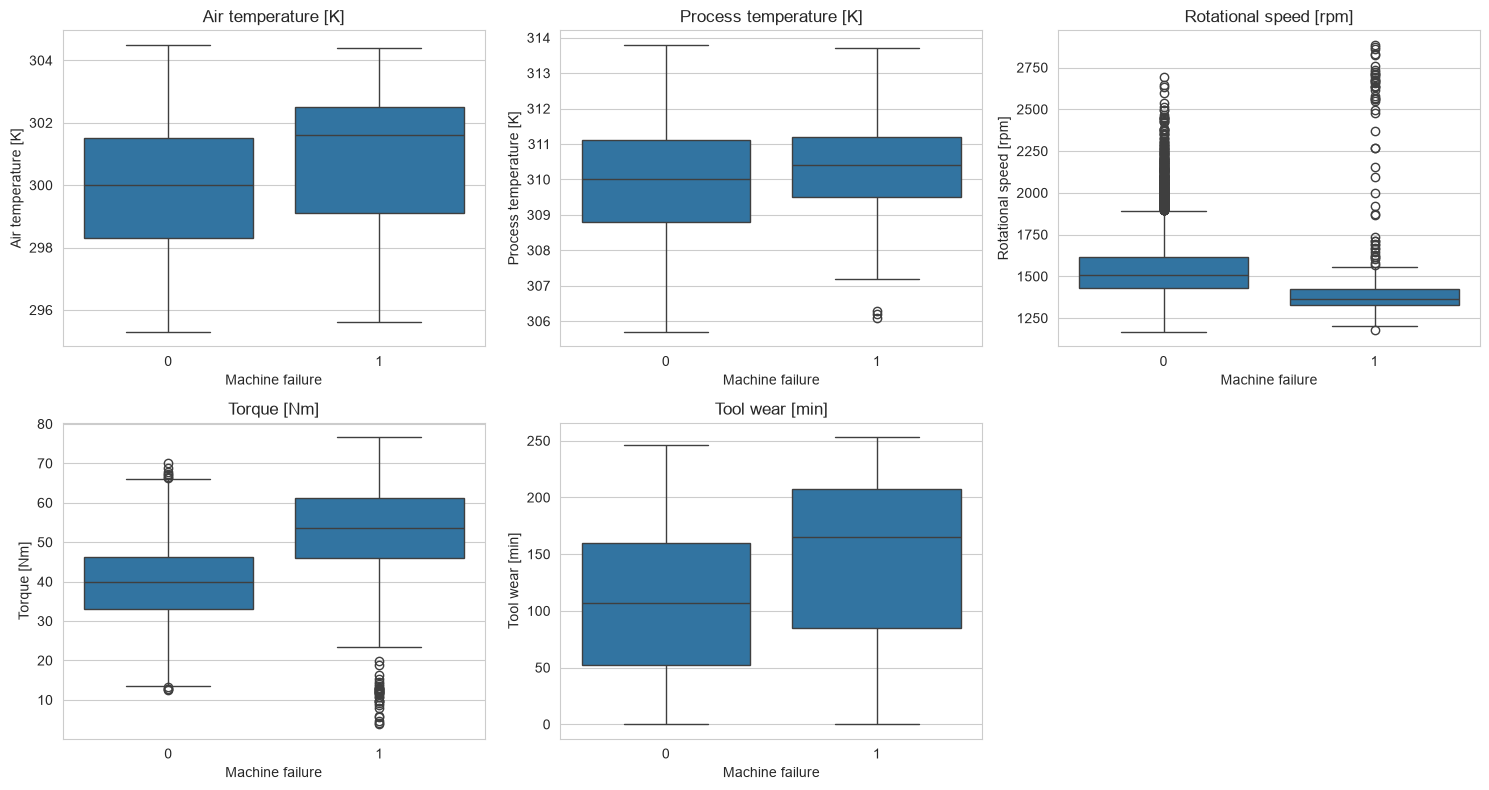

In [146]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(2, 3, i)

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=col
    )

    plt.title(col)

plt.tight_layout()

plt.show()

#### 2.5 . Multicollinearity

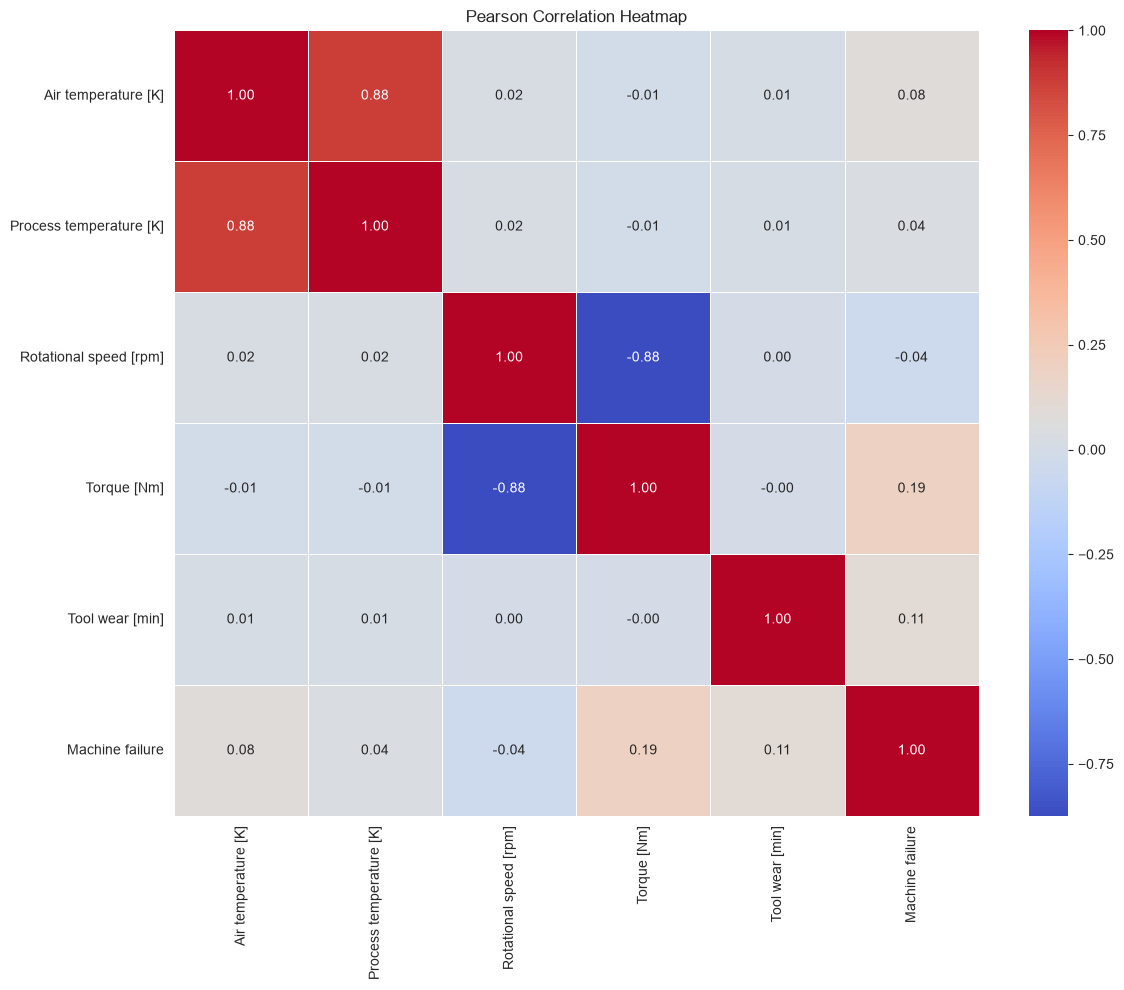

In [147]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df[numerical_cols + ["Machine failure"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()

plt.show()

#### 2.6 . Linear Seperability

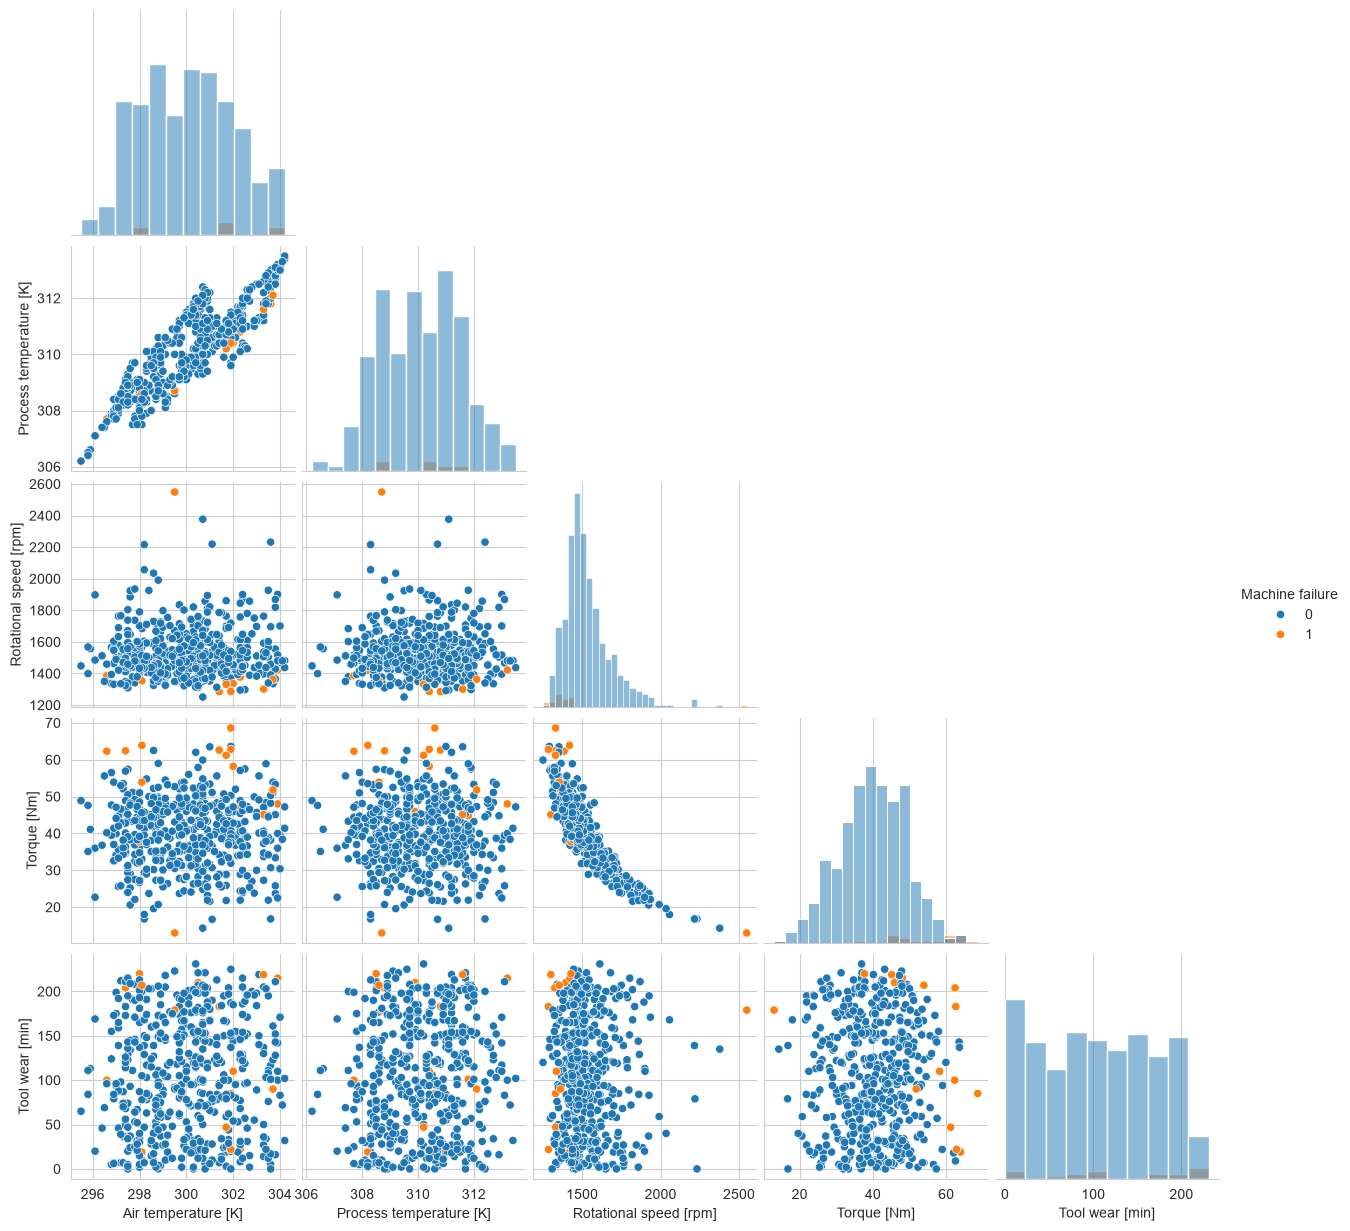

In [148]:
# Random sample for visualization
sample = df.sample(n=500, random_state=42)

# Pairplot
sns.pairplot(
    sample,
    vars=[
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ],
    hue="Machine failure",
    corner=True,
    diag_kind="hist"
)

plt.show()

## 3. Data Preprocessing 

####  3.1 create dataset

In [149]:
 
train = df.copy()
train.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


#### 3.2 Remove unnecessary columns 

In [150]:
# drop identifier columns
train.drop (
    columns = [
        "UDI",
        "Product ID"  
    ],
    inplace=True
)

# drop data leakage column
train.drop(
    columns = [
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF",
    ],
    inplace=True
) 



In [151]:
train.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


#### 3.3 define features and targets

In [152]:
X = train.drop(columns = "Machine failure")
y = train["Machine failure"]

#### 3.4 train-test-split

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### 3.5 pre-processing pipeline 

In [154]:
# group features 
categorical_features = [
    "Type"
]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

#### Encoding categorical and numerical features and preprocessing 

In [155]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

## 4.0 Model Selection

#### 4.1 Baseline models

In [156]:

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)


#### train the baseline model

In [157]:
logistic_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Type','Air temperature [K]','Process temperature [K]', 'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

#### make predictions 

In [158]:
# Predictions on the test set
y_pred = logistic_pipeline.predict(X_test)

# Predicted probabilities
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

#### Evaluation metrics - logistic regression

In [159]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.9675
Precision: 0.6363636363636364
Recall   : 0.10294117647058823
F1 Score : 0.17721518987341772


#### Classification report

In [160]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



#### Confusion matrix 

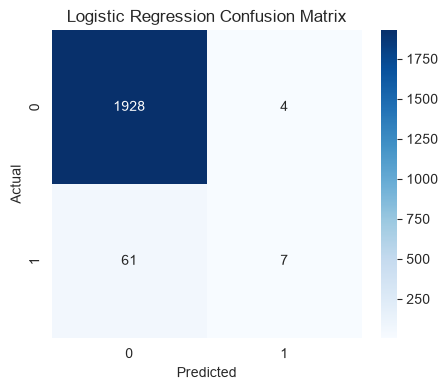

In [161]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

#### Cross validation

In [162]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Cross Validation F1 Scores")
print(cv_scores)

print("Mean F1:", cv_scores.mean())

Cross Validation F1 Scores
[0.29850746 0.34782609 0.33766234 0.28125    0.29411765]
Mean F1: 0.31187270687285007


#### 4.2 Model Selection

In [163]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

from xgboost import XGBClassifier

#### Create model dictionaries 

In [164]:
models = {

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

}

In [165]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

import time

In [166]:
results = []

trained_models = {}

#### Train every model

In [167]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score
)


for model_name, model in models.items():

    print(f"Training {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

    # 5-Fold Cross Validation
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_f1 = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    # Train the model
    start = time.time()

    pipeline.fit(
        X_train,
        y_train
    )

    training_time = time.time() - start

    # Save trained model
    trained_models[model_name] = pipeline

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Store evaluation metrics
    results.append({

        "Model": model_name,

        "CV F1": cv_f1.mean(),

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F2 Score": fbeta_score(
            y_test,
            y_pred,
            beta=2,
            zero_division=0
        ),

        "Training Time (s)": training_time

    })

    print(f"✓ Finished {model_name}")

print(f"\nTotal trained models: {len(trained_models)}")
print(f"Total result rows: {len(results)}")

Training Decision Tree...
✓ Finished Decision Tree
Training Random Forest...
✓ Finished Random Forest
Training Gradient Boosting...
✓ Finished Gradient Boosting
Training Support Vector Machine...


c:\Users\HAZEL\Desktop\ML1_Capstone\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\HAZEL\Desktop\ML1_Capstone\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\HAZEL\Desktop\ML1_Capstone\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\HAZEL\Desktop\ML1_Capstone\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter

✓ Finished Support Vector Machine
Training XGBoost...
✓ Finished XGBoost

Total trained models: 5
Total result rows: 5


In [168]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F2 Score",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,CV F1,Accuracy,Precision,Recall,F1 Score,F2 Score,Training Time (s)
0,XGBoost,0.706542,0.9880,0.907407,0.720588,0.803279,0.751534,0.216942
1,Gradient Boosting,0.708991,0.9855,0.882353,0.661765,0.756303,0.696594,1.848881
2,Decision Tree,0.698955,0.9775,0.671642,0.661765,0.666667,0.663717,0.096523
3,Random Forest,0.627710,0.9820,0.900000,0.529412,0.666667,0.576923,1.496479
4,Support Vector Machine,0.391411,0.9720,0.875000,0.205882,0.333333,0.243056,3.179854


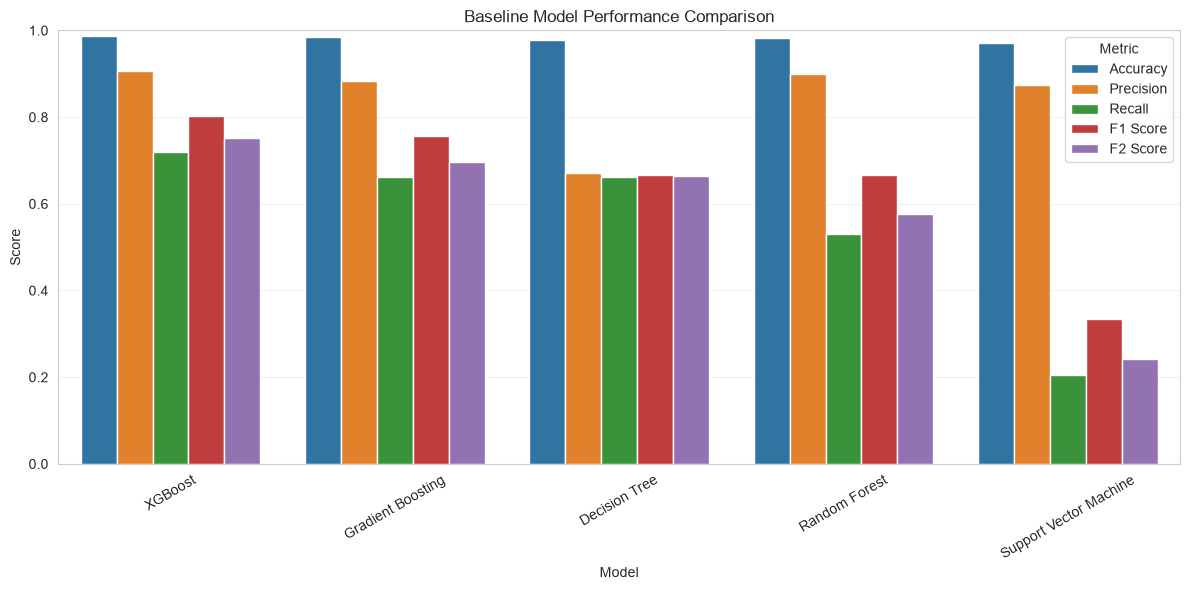

In [169]:
plot_df = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "F2 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Baseline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

displaying the learning curves 

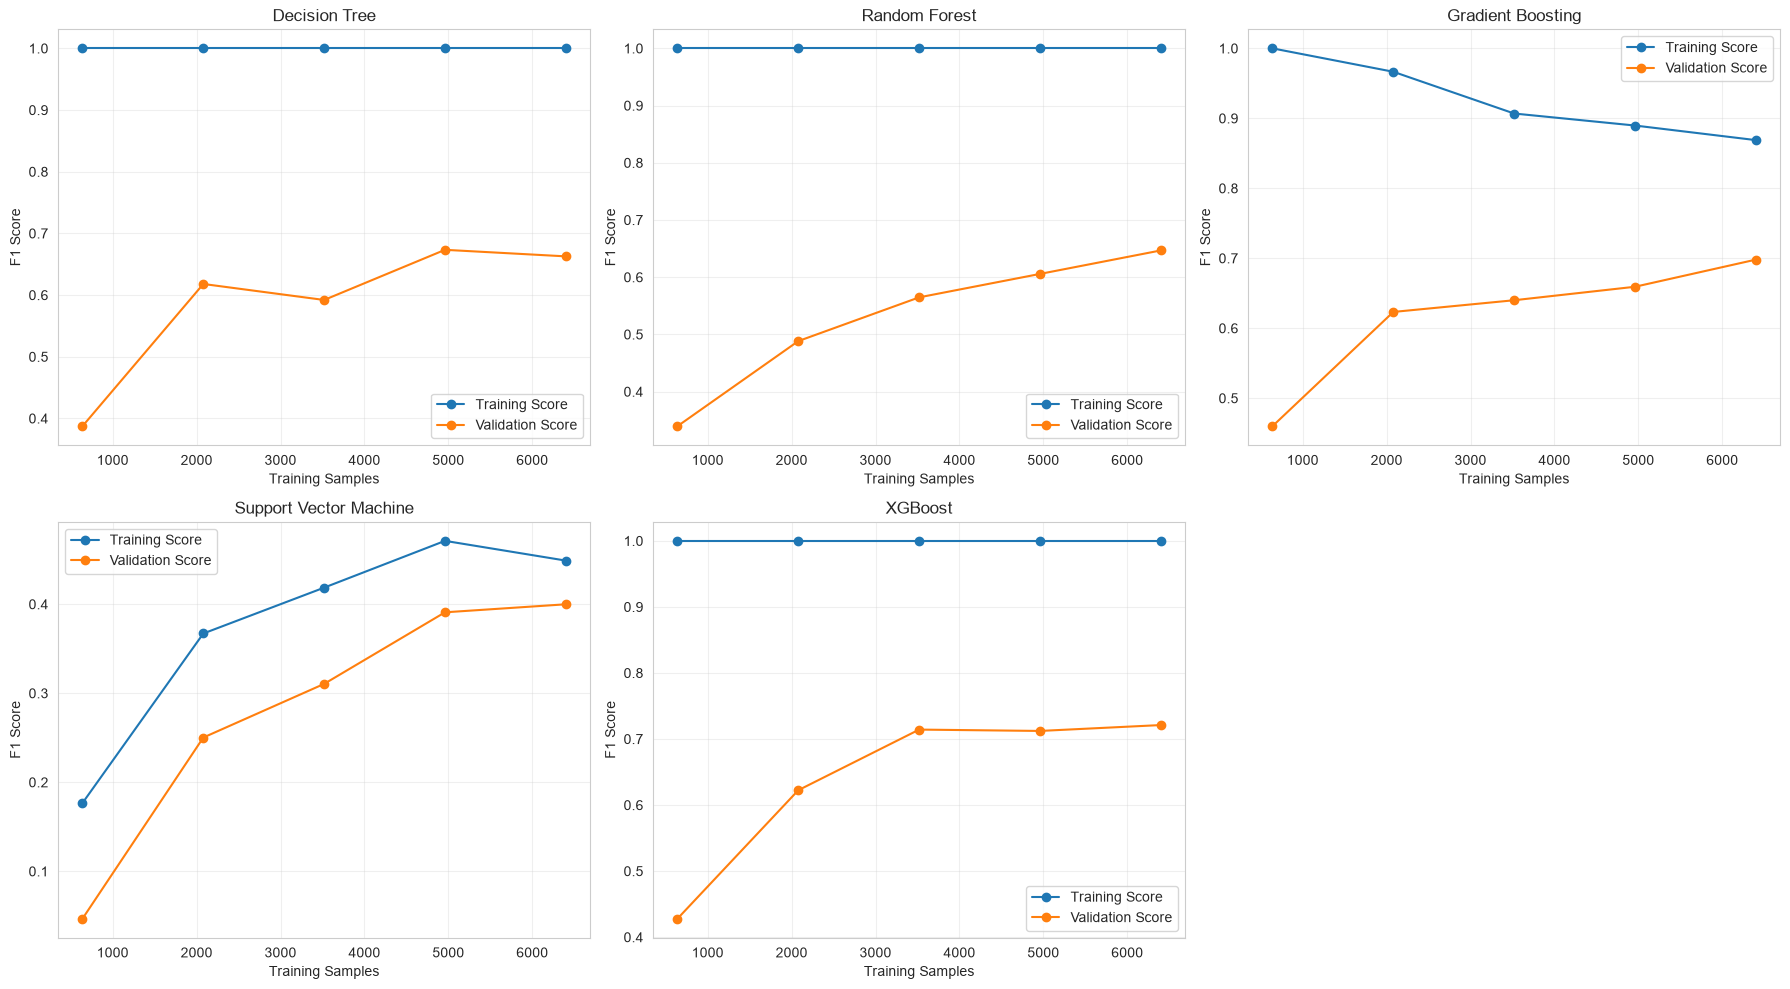

In [170]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.ravel()

for i, (model_name, model) in enumerate(models.items()):

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=5,
        scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    axes[i].plot(
        train_sizes,
        train_mean,
        marker="o",
        label="Training Score"
    )

    axes[i].plot(
        train_sizes,
        validation_mean,
        marker="o",
        label="Validation Score"
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel("Training Samples")
    axes[i].set_ylabel("F1 Score")
    axes[i].grid(alpha=0.3)

    # Legend for each subplot
    axes[i].legend(loc="best")

# Hide the unused sixth subplot
axes[-1].axis("off")

plt.tight_layout()

plt.show()

In [171]:
print(X_train.columns.tolist())
print(numerical_features)

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


#### Feature Engineering

 create a copy 

In [172]:
# Copy the cleaned baseline dataset
train_fe = train.copy()

In [173]:
# Heat Dissipation
train_fe["Heat Dissipation"] = (
    train_fe["Process temperature [K]"]
    - train_fe["Air temperature [K]"]
)

# Mechanical Power
train_fe["Power"] = (
    (2 * np.pi * train_fe["Rotational speed [rpm]"]
     * train_fe["Torque [Nm]"]) / 60
)

# Mechanical Overstrain
train_fe["Overstrain"] = (
    train_fe["Torque [Nm]"]
    * train_fe["Tool wear [min]"]
)

In [174]:
train_fe.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Heat Dissipation,Power,Overstrain
0,M,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,0.0
1,L,298.2,308.7,1408,46.3,3,0,10.5,6826.722724,138.9
2,L,298.1,308.5,1498,49.4,5,0,10.4,7749.387543,247.0
3,L,298.2,308.6,1433,39.5,7,0,10.4,5927.504659,276.5
4,L,298.2,308.7,1408,40.0,9,0,10.5,5897.816608,360.0


In [175]:
train_fe[
    [
        "Heat Dissipation",
        "Power",
        "Overstrain"
    ]
].describe()

,Heat Dissipation,Power,Overstrain
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,4314.664550
std,1.001094,1067.418295,2826.567692
min,7.600000,1148.440610,0.000000
25%,9.300000,5561.184484,1963.650000
50%,9.800000,6271.027344,4012.950000
75%,11.000000,7003.002724,6279.000000
max,12.100000,10469.923005,16497.000000


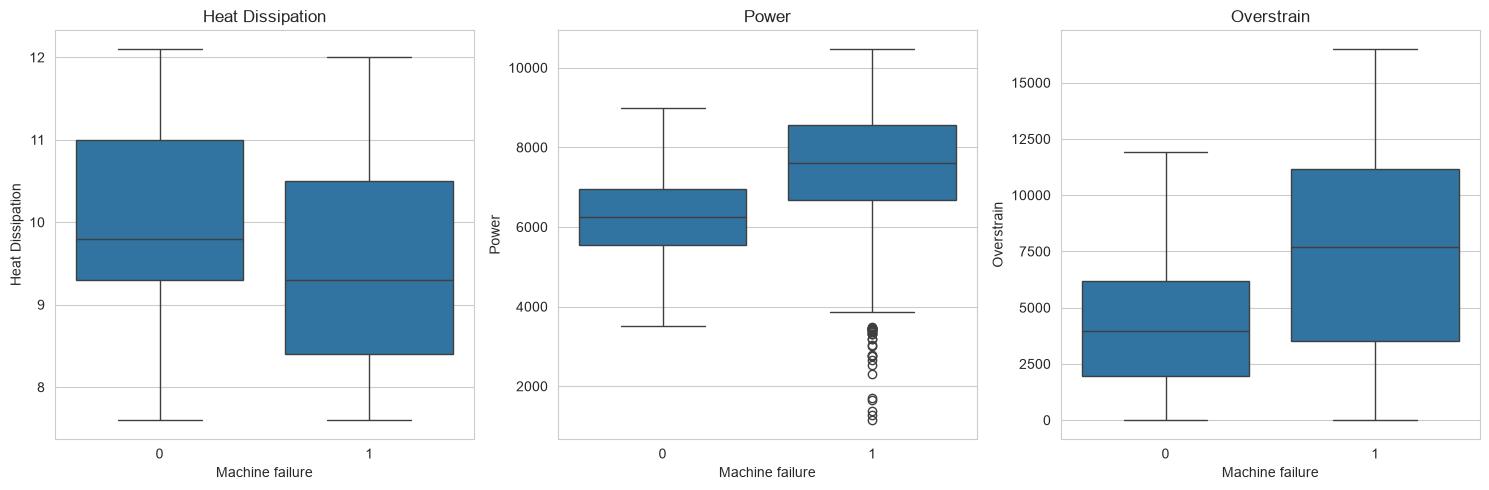

In [176]:
# Visualise the engineered features

engineered_features = [
    "Heat Dissipation",
    "Power",
    "Overstrain"
]

plt.figure(figsize=(15,5))

for i, feature in enumerate(engineered_features, 1):

    plt.subplot(1,3,i)

    sns.boxplot(
        data=train_fe,
        x="Machine failure",
        y=feature
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

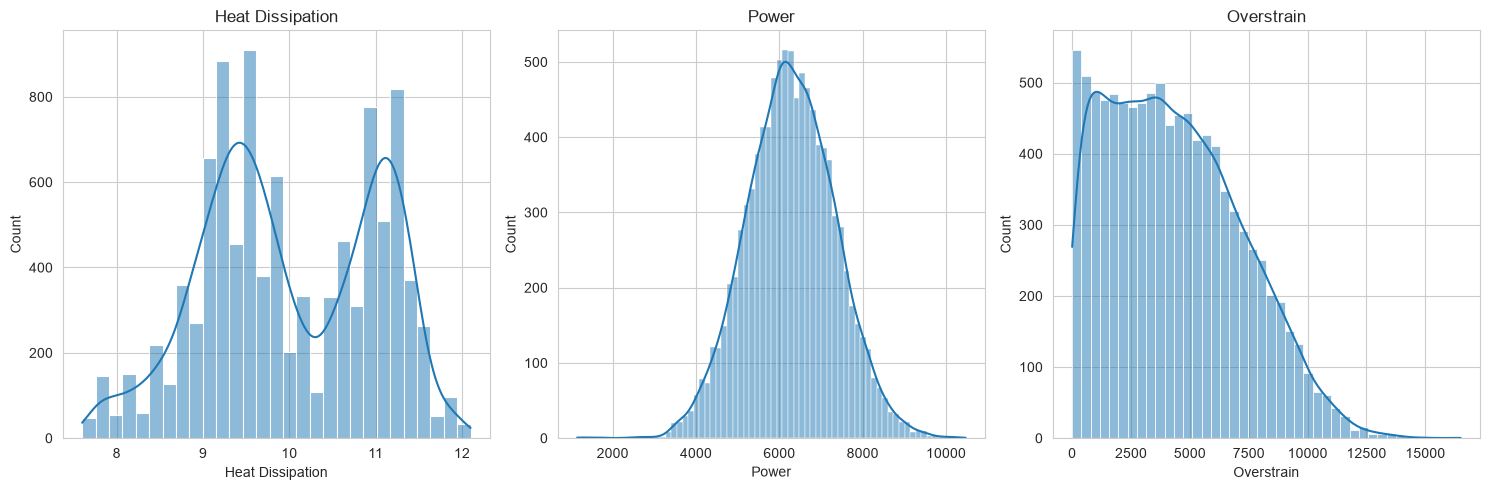

In [177]:
plt.figure(figsize=(15,5))

for i, feature in enumerate(engineered_features, 1):

    plt.subplot(1,3,i)

    sns.histplot(
        train_fe[feature],
        kde=True
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

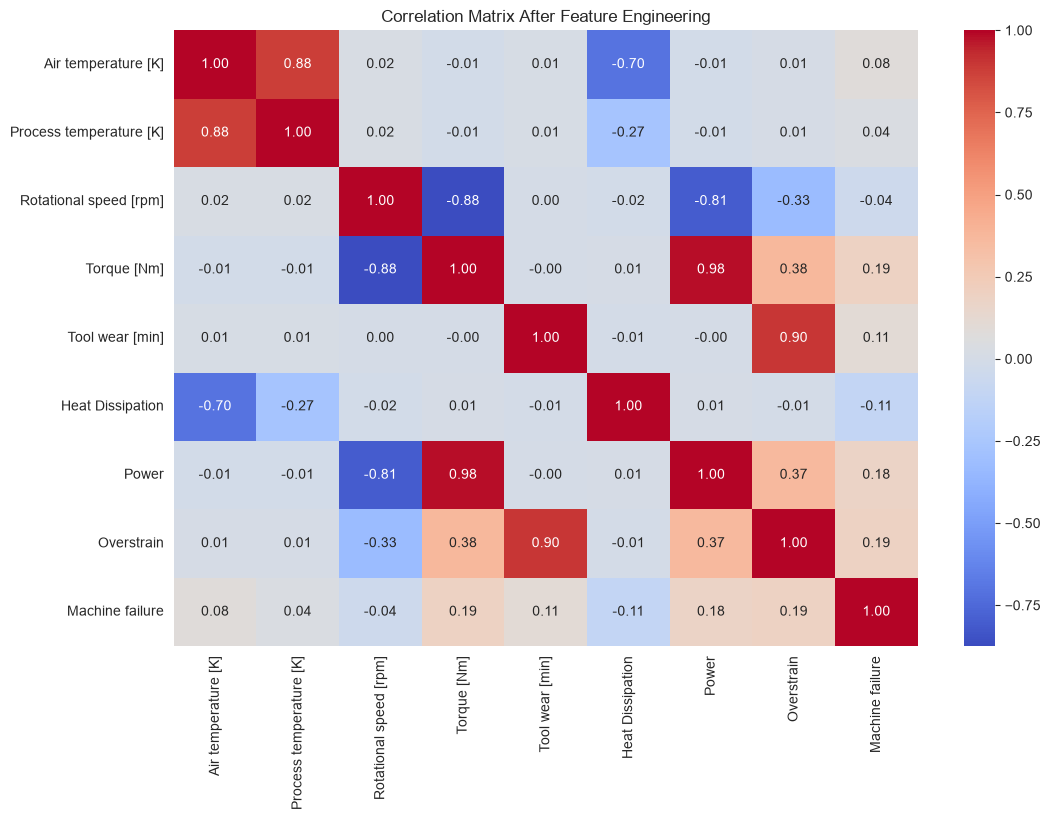

In [178]:
updated_numerical_cols = [

    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Heat Dissipation",
    "Power",
    "Overstrain",
    "Machine failure"

]

plt.figure(figsize=(12,8))

sns.heatmap(
    train_fe[updated_numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix After Feature Engineering")

plt.show()

#### Updating the preprocessing pipeline

In [179]:
numerical_features = [

    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Heat Dissipation",
    "Power",
    "Overstrain"

]

categorical_features = [

    "Type"

]

In [180]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [181]:
X_fe = train_fe.drop(
    "Machine failure",
    axis=1
)

y_fe = train_fe["Machine failure"]

#### train-test split 

In [182]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(

    X_fe,
    y_fe,

    test_size=0.20,
    stratify=y_fe,
    random_state=42

)

#### Train models after feature engineering 

In [183]:
trained_models_fe = {}

results_fe = []

In [184]:
for model_name, model in models.items():

    print(f"Training {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_fe),
            ("classifier", model)
        ]
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_f1 = cross_val_score(
        pipeline,
        X_train_fe,
        y_train_fe,
        cv=cv,
        scoring="f1"
    )

    start = time.time()

    pipeline.fit(
        X_train_fe,
        y_train_fe
    )

    training_time = time.time() - start

    trained_models_fe[model_name] = pipeline

    y_pred = pipeline.predict(X_test_fe)

    results_fe.append({

        "Model": model_name,

        "CV F1": cv_f1.mean(),

        "Accuracy": accuracy_score(
            y_test_fe,
            y_pred
        ),

        "Precision": precision_score(
            y_test_fe,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test_fe,
            y_pred,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test_fe,
            y_pred,
            zero_division=0
        ),

        "F2 Score": fbeta_score(
            y_test_fe,
            y_pred,
            beta=2,
            zero_division=0
        ),

        "Training Time (s)": training_time

    })

    print(f"✓ Finished {model_name}")

print(f"\nTotal trained models: {len(trained_models_fe)}")
print(f"Total result rows: {len(results_fe)}")

Training Decision Tree...
✓ Finished Decision Tree
Training Random Forest...
✓ Finished Random Forest
Training Gradient Boosting...
✓ Finished Gradient Boosting
Training Support Vector Machine...


c:\Users\HAZEL\Desktop\ML1_Capstone\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\HAZEL\Desktop\ML1_Capstone\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\HAZEL\Desktop\ML1_Capstone\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\HAZEL\Desktop\ML1_Capstone\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter

✓ Finished Support Vector Machine
Training XGBoost...
✓ Finished XGBoost

Total trained models: 5
Total result rows: 5


In [185]:
results_fe_df = pd.DataFrame(results_fe)

results_fe_df.columns

Index(['Model', 'CV F1', 'Accuracy', 'Precision', 'Recall', 'F1 Score',
       'F2 Score', 'Training Time (s)'],
      dtype='str')

In [186]:
results_fe_df = results_fe_df.sort_values(
    by="F2 Score",
    ascending=False
)

results_fe_df.reset_index(
    drop=True,
    inplace=True
)

results_fe_df

,Model,CV F1,Accuracy,Precision,Recall,F1 Score,F2 Score,Training Time (s)
0,XGBoost,0.826523,0.9910,0.903226,0.823529,0.861538,0.838323,0.223078
1,Random Forest,0.879991,0.9925,0.964912,0.808824,0.880000,0.835866,2.434232
2,Gradient Boosting,0.890606,0.9930,1.000000,0.794118,0.885246,0.828221,2.910581
3,Decision Tree,0.829262,0.9875,0.830769,0.794118,0.812030,0.801187,0.082683
4,Support Vector Machine,0.485746,0.9765,0.888889,0.352941,0.505263,0.401338,3.334527


In [187]:
baseline_results = results_df.copy()

feature_engineering_results = results_fe_df.copy()

In [188]:
baseline_results = baseline_results.rename(columns={

    "Accuracy": "Baseline Accuracy",
    "Precision": "Baseline Precision",
    "Recall": "Baseline Recall",
    "F1 Score": "Baseline F1",
    "F2 Score": "Baseline F2"

})

feature_engineering_results = feature_engineering_results.rename(columns={

    "Accuracy": "FE Accuracy",
    "Precision": "FE Precision",
    "Recall": "FE Recall",
    "F1 Score": "FE F1",
    "F2 Score": "FE F2"

})

In [189]:
comparison_df = baseline_results.merge(

    feature_engineering_results,

    on="Model"

)

comparison_df

,Model,CV F1_x,Baseline Accuracy,Baseline Precision,Baseline Recall,Baseline F1,Baseline F2,Training Time (s)_x,CV F1_y,FE Accuracy,FE Precision,FE Recall,FE F1,FE F2,Training Time (s)_y
0,XGBoost,0.706542,0.9880,0.907407,0.720588,0.803279,0.751534,0.216942,0.826523,0.9910,0.903226,0.823529,0.861538,0.838323,0.223078
1,Gradient Boosting,0.708991,0.9855,0.882353,0.661765,0.756303,0.696594,1.848881,0.890606,0.9930,1.000000,0.794118,0.885246,0.828221,2.910581
2,Decision Tree,0.698955,0.9775,0.671642,0.661765,0.666667,0.663717,0.096523,0.829262,0.9875,0.830769,0.794118,0.812030,0.801187,0.082683
3,Random Forest,0.627710,0.9820,0.900000,0.529412,0.666667,0.576923,1.496479,0.879991,0.9925,0.964912,0.808824,0.880000,0.835866,2.434232
4,Support Vector Machine,0.391411,0.9720,0.875000,0.205882,0.333333,0.243056,3.179854,0.485746,0.9765,0.888889,0.352941,0.505263,0.401338,3.334527


In [190]:
comparison_df["Recall Improvement"] = (
    comparison_df["FE Recall"]
    - comparison_df["Baseline Recall"]
)

comparison_df["F1 Improvement"] = (
    comparison_df["FE F1"]
    - comparison_df["Baseline F1"]
)

comparison_df["F2 Improvement"] = (
    comparison_df["FE F2"]
    - comparison_df["Baseline F2"]
)

comparison_df

,Model,CV F1_x,Baseline Accuracy,Baseline Precision,Baseline Recall,Baseline F1,Baseline F2,Training Time (s)_x,CV F1_y,FE Accuracy,FE Precision,FE Recall,FE F1,FE F2,Training Time (s)_y,Recall Improvement,F1 Improvement,F2 Improvement
0,XGBoost,0.706542,0.9880,0.907407,0.720588,0.803279,0.751534,0.216942,0.826523,0.9910,0.903226,0.823529,0.861538,0.838323,0.223078,0.102941,0.058260,0.086790
1,Gradient Boosting,0.708991,0.9855,0.882353,0.661765,0.756303,0.696594,1.848881,0.890606,0.9930,1.000000,0.794118,0.885246,0.828221,2.910581,0.132353,0.128943,0.131626
2,Decision Tree,0.698955,0.9775,0.671642,0.661765,0.666667,0.663717,0.096523,0.829262,0.9875,0.830769,0.794118,0.812030,0.801187,0.082683,0.132353,0.145363,0.137470
3,Random Forest,0.627710,0.9820,0.900000,0.529412,0.666667,0.576923,1.496479,0.879991,0.9925,0.964912,0.808824,0.880000,0.835866,2.434232,0.279412,0.213333,0.258943
4,Support Vector Machine,0.391411,0.9720,0.875000,0.205882,0.333333,0.243056,3.179854,0.485746,0.9765,0.888889,0.352941,0.505263,0.401338,3.334527,0.147059,0.171930,0.158282


**XGBOOST** - 
Recall increased by 10.3% |
F1 increased by 5.8%

F2 increased by 8.7%

The engineered features allowed XGBoost to detect more failing machines while maintaining high precision. Since XGBoost already captures complex feature interactions, the improvement is meaningful but not dramatic.


**Gradient Boosting**
Recall increased by over 13%, while both F1 and F2 improved substantially. The sequential boosting process benefited from the engineered variables because they exposed clearer relationships between thermal and mechanical operating conditions.

**Decision Tree**
Decision Trees depend heavily on informative features because each split is based on a single variable. By adding physically meaningful variables, the tree could create much better decision boundaries, leading to noticeable gains across all evaluation metrics.

**Random Forest**
Recall improved by 27.9 percentage points, which is enormous.

That means before feature engineering the model was missing almost half of machine failures, whereas after engineering it successfully detected more than 80% of failures.

Since Random Forest builds many decision trees using random subsets of features, adding informative engineered variables greatly increased the diversity and quality of the trees.

**SVM**

Although SVM remains the weakest model, it still benefited from the engineered features. The additional variables made the classes more separable, allowing the decision boundary to identify more machine failures.

**CONCLUSION AFTER FEATURE ENGINEERING**

The derived features—Heat Dissipation, Power, and Overstrain—captured operational characteristics that were not explicitly represented in the original sensor measurements. These additional variables increased the models' ability to distinguish between healthy and failing machines, resulting in consistent improvements in Recall, F1 Score, and F2 Score across all classifiers.



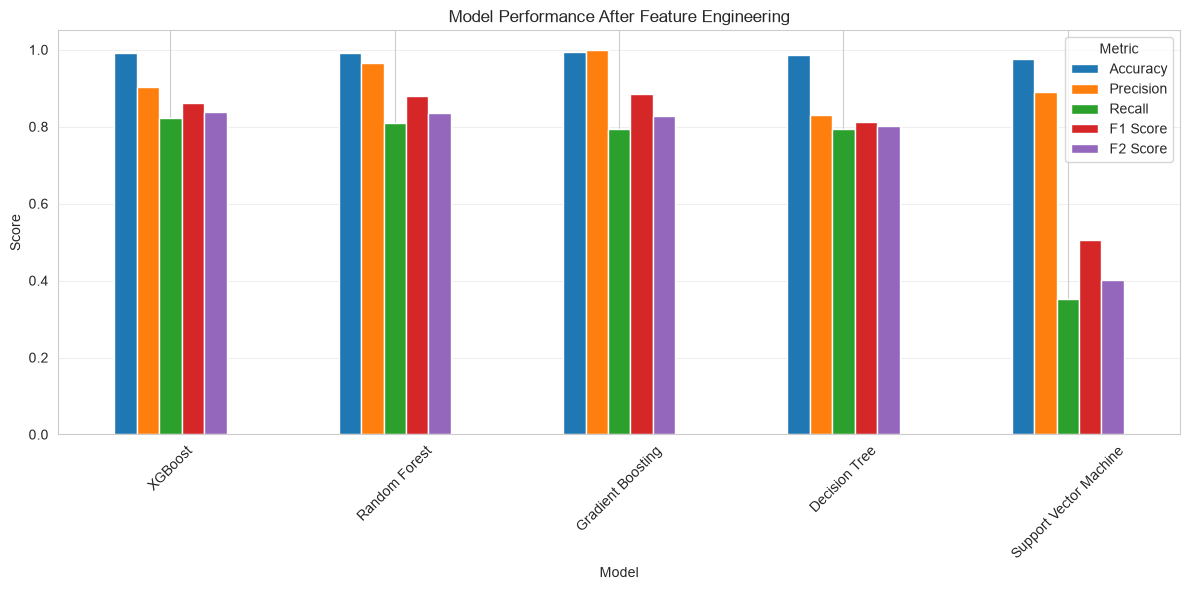

In [191]:
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "F2 Score"
]

plot_df = results_fe_df.set_index("Model")[metrics]

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance After Feature Engineering")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

#### class imbalance using smote 

In [192]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [193]:
smote = SMOTE(

    random_state=42

)

In [194]:
# Feature Engineering + SMOTE pipeline

smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("smote", SMOTE(random_state=42))
    ]
)

X_train_smote, y_train_smote = smote_pipeline.fit_resample(
    X_train_fe,
    y_train_fe
)

In [195]:
pd.Series(y_train_smote).value_counts()

Machine failure
0    7729
1    7729
Name: count, dtype: int64

In [196]:
print("Original Training Distribution")
print(y_train_fe.value_counts())

print("\nSMOTE Training Distribution")
print(pd.Series(y_train_smote).value_counts())

Original Training Distribution
Machine failure
0    7729
1     271
Name: count, dtype: int64

SMOTE Training Distribution
Machine failure
0    7729
1    7729
Name: count, dtype: int64


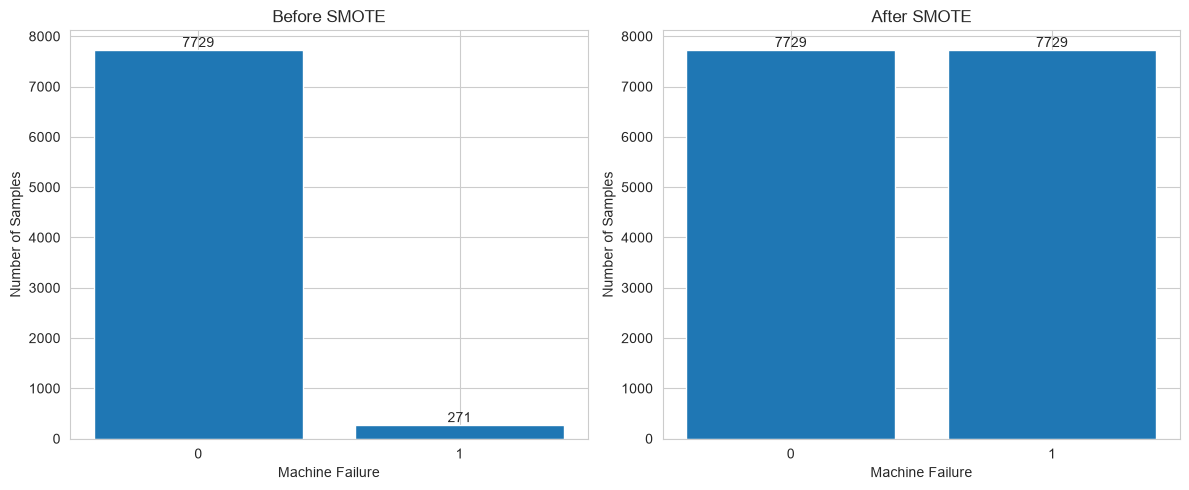

In [197]:
original_counts = y_train_fe.value_counts()

smote_counts = pd.Series(y_train_smote).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    original_counts.index.astype(str),
    original_counts.values
)

axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Machine Failure")
axes[0].set_ylabel("Number of Samples")

for i, value in enumerate(original_counts.values):
    axes[0].text(i, value, str(value), ha="center", va="bottom")

axes[1].bar(
    smote_counts.index.astype(str),
    smote_counts.values
)

axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Machine Failure")
axes[1].set_ylabel("Number of Samples")

for i, value in enumerate(smote_counts.values):
    axes[1].text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()

plt.show()

For example, if the model predicts every machine as healthy, it would still achieve around 96.6% accuracy, 
but it would fail to identify machines that are actually about to fail.

In predictive maintenance, missing a failure is much more costly than incorrectly flagging a healthy machine,
 making class imbalance a significant issue.

**why didnt I use random Oversampling?**

Random oversampling simply duplicates existing minority class examples.The model repeatedly sees the same failure examples and may memorize them instead of learning general failure patterns, increasing the risk of overfitting.

**why didnt I use random undersampling?**

Random undersampling removes samples from the majority class.Although the classes become balanced, more than 7,400 healthy machine observations are discarded.

For predictive maintenance, healthy operating data is valuable because it teaches the model what normal machine behaviour looks like.

Removing most of these observations results in a substantial loss of information.

**why smote**  Synthetic Minority Oversampling Technique

creates new synthetic failure samples instead of simply copying existing ones.

It balances the classes without discarding healthy machine data and without creating exact duplicates of failure cases.

This allows the model to learn a broader representation of failure behaviour while preserving all available information about normal machine operation.

This new sample did not exist in the original dataset, but it represents a realistic machine operating condition because it lies between two actual failure examples.

SMOTE repeats this process until the minority class reaches the desired size.

**conclusion**

The graph shows that SMOTE has successfully addressed the class imbalance in the training dataset by increasing the number of minority class (machine failure) samples until it matches the number of majority class (healthy machine) samples.

As a result, the model is less likely to become biased toward predicting healthy machines and is more likely to detect failure patterns.

SMOTE was selected because machine failures are naturally rare events, resulting in a highly imbalanced dataset. Unlike random undersampling, SMOTE preserves all healthy machine observations, preventing the loss of valuable information about normal operating conditions. Unlike random oversampling, it does not simply duplicate failure cases, which can lead to overfitting. Instead, SMOTE generates new synthetic failure samples by interpolating between existing failure observations, enabling the model to learn a more generalized representation of machine failure patterns. This makes it particularly well suited for predictive maintenance, where accurately identifying rare failure events is more important than achieving high overall accuracy.



In [198]:
trained_models_smote = {}
results_smote = []

for model_name, model in models.items():

    print(f"Training {model_name} with FE + SMOTE...")

    pipeline = ImbPipeline(
        steps=[
            ("preprocessor", preprocessor_fe),
            ("smote", SMOTE(random_state=42)),
            ("classifier", model)
        ]
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_f1 = cross_val_score(
        pipeline,
        X_train_fe,
        y_train_fe,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    start = time.time()

    pipeline.fit(
        X_train_fe,
        y_train_fe
    )

    training_time = time.time() - start

    trained_models_smote[model_name] = pipeline

    y_pred = pipeline.predict(X_test_fe)

    results_smote.append({

        "Model": model_name,

        "CV F1": cv_f1.mean(),

        "Accuracy": accuracy_score(
            y_test_fe,
            y_pred
        ),

        "Precision": precision_score(
            y_test_fe,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test_fe,
            y_pred,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test_fe,
            y_pred,
            zero_division=0
        ),

        "F2 Score": fbeta_score(
            y_test_fe,
            y_pred,
            beta=2,
            zero_division=0
        ),

        "Training Time (s)": training_time
    })

    print(f"✓ Finished {model_name}")

Training Decision Tree with FE + SMOTE...
✓ Finished Decision Tree
Training Random Forest with FE + SMOTE...
✓ Finished Random Forest
Training Gradient Boosting with FE + SMOTE...
✓ Finished Gradient Boosting
Training Support Vector Machine with FE + SMOTE...


c:\Users\HAZEL\Desktop\ML1_Capstone\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


✓ Finished Support Vector Machine
Training XGBoost with FE + SMOTE...
✓ Finished XGBoost


In [199]:
results_smote_df = pd.DataFrame(results_smote)

In [200]:
results_smote_df = results_smote_df.sort_values(
    by="F2 Score",
    ascending=False
)

results_smote_df.reset_index(
    drop=True,
    inplace=True
)

results_smote_df

,Model,CV F1,Accuracy,Precision,Recall,F1 Score,F2 Score,Training Time (s)
0,Random Forest,0.768361,0.9805,0.670588,0.838235,0.745098,0.798319,5.807934
1,XGBoost,0.783356,0.9800,0.670732,0.808824,0.733333,0.776836,0.611200
2,Gradient Boosting,0.622928,0.9610,0.460938,0.867647,0.602041,0.737500,4.419597
3,Decision Tree,0.652704,0.9705,0.544554,0.808824,0.650888,0.737265,0.258815
4,Support Vector Machine,0.462391,0.9270,0.305000,0.897059,0.455224,0.646186,22.870510


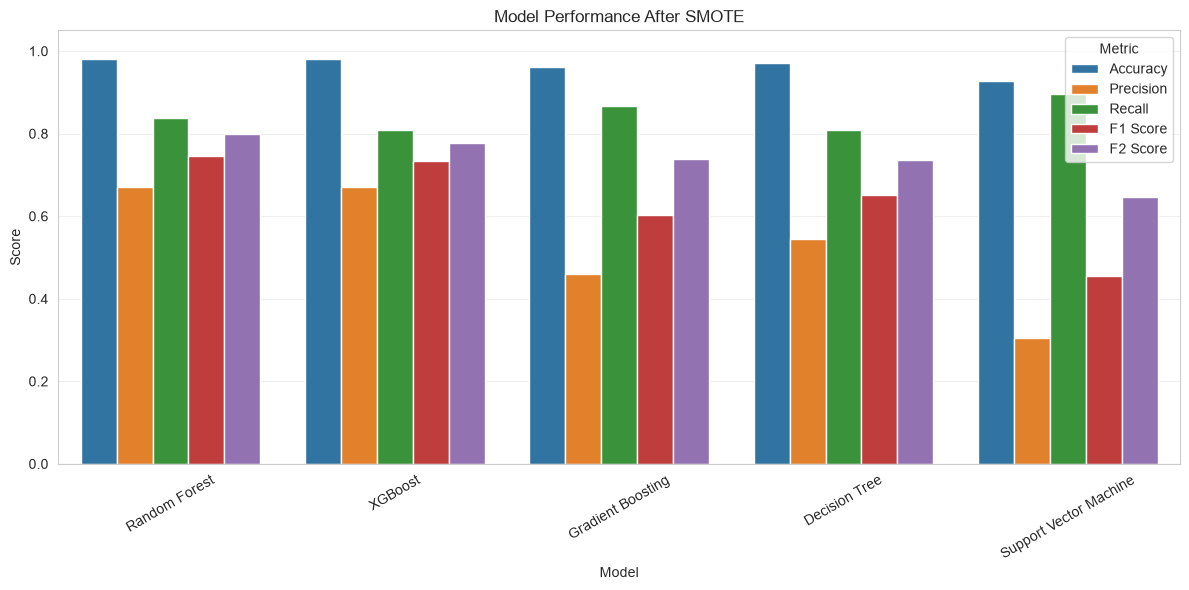

In [201]:
plot_df = results_smote_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "F2 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance After SMOTE")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.legend(title="Metric")

plt.tight_layout()

plt.show()

In [202]:
baseline_results = results_df.copy()

feature_engineering_results = results_fe_df.copy()

smote_results = results_smote_df.copy()

In [203]:
baseline_results = baseline_results.rename(columns={

    "Accuracy": "Baseline Accuracy",
    "Precision": "Baseline Precision",
    "Recall": "Baseline Recall",
    "F1 Score": "Baseline F1",
    "F2 Score": "Baseline F2"

})

feature_engineering_results = feature_engineering_results.rename(columns={

    "Accuracy": "FE Accuracy",
    "Precision": "FE Precision",
    "Recall": "FE Recall",
    "F1 Score": "FE F1",
    "F2 Score": "FE F2"

})

smote_results = smote_results.rename(columns={

    "Accuracy": "SMOTE Accuracy",
    "Precision": "SMOTE Precision",
    "Recall": "SMOTE Recall",
    "F1 Score": "SMOTE F1",
    "F2 Score": "SMOTE F2"

})

In [204]:
baseline_results = baseline_results[[
    "Model",
    "Baseline Accuracy",
    "Baseline Precision",
    "Baseline Recall",
    "Baseline F1",
    "Baseline F2"
]]

feature_engineering_results = feature_engineering_results[[
    "Model",
    "FE Accuracy",
    "FE Precision",
    "FE Recall",
    "FE F1",
    "FE F2"
]]

smote_results = smote_results[[
    "Model",
    "SMOTE Accuracy",
    "SMOTE Precision",
    "SMOTE Recall",
    "SMOTE F1",
    "SMOTE F2"
]]

In [205]:
comparison_df = baseline_results.merge(

    feature_engineering_results,
    on="Model"

).merge(

    smote_results,
    on="Model"

)

In [206]:
comparison_df["Recall Improvement (FE)"] = (

    comparison_df["FE Recall"]
    - comparison_df["Baseline Recall"]

)

comparison_df["Recall Improvement (SMOTE)"] = (

    comparison_df["SMOTE Recall"]
    - comparison_df["Baseline Recall"]

)

comparison_df["F1 Improvement (FE)"] = (

    comparison_df["FE F1"]
    - comparison_df["Baseline F1"]

)

comparison_df["F1 Improvement (SMOTE)"] = (

    comparison_df["SMOTE F1"]
    - comparison_df["Baseline F1"]

)

comparison_df["F2 Improvement (FE)"] = (

    comparison_df["FE F2"]
    - comparison_df["Baseline F2"]

)

comparison_df["F2 Improvement (SMOTE)"] = (

    comparison_df["SMOTE F2"]
    - comparison_df["Baseline F2"]

)

comparison_df

,Model,Baseline Accuracy,Baseline Precision,Baseline Recall,Baseline F1,Baseline F2,FE Accuracy,FE Precision,FE Recall,FE F1,FE F2,SMOTE Accuracy,SMOTE Precision,SMOTE Recall,SMOTE F1,SMOTE F2,Recall Improvement (FE),Recall Improvement (SMOTE),F1 Improvement (FE),F1 Improvement (SMOTE),F2 Improvement (FE),F2 Improvement (SMOTE)
0,XGBoost,0.9880,0.907407,0.720588,0.803279,0.751534,0.9910,0.903226,0.823529,0.861538,0.838323,0.9800,0.670732,0.808824,0.733333,0.776836,0.102941,0.088235,0.058260,-0.069945,0.086790,0.025302
1,Gradient Boosting,0.9855,0.882353,0.661765,0.756303,0.696594,0.9930,1.000000,0.794118,0.885246,0.828221,0.9610,0.460938,0.867647,0.602041,0.737500,0.132353,0.205882,0.128943,-0.154262,0.131626,0.040906
2,Decision Tree,0.9775,0.671642,0.661765,0.666667,0.663717,0.9875,0.830769,0.794118,0.812030,0.801187,0.9705,0.544554,0.808824,0.650888,0.737265,0.132353,0.147059,0.145363,-0.015779,0.137470,0.073549
3,Random Forest,0.9820,0.900000,0.529412,0.666667,0.576923,0.9925,0.964912,0.808824,0.880000,0.835866,0.9805,0.670588,0.838235,0.745098,0.798319,0.279412,0.308824,0.213333,0.078431,0.258943,0.221396
4,Support Vector Machine,0.9720,0.875000,0.205882,0.333333,0.243056,0.9765,0.888889,0.352941,0.505263,0.401338,0.9270,0.305000,0.897059,0.455224,0.646186,0.147059,0.691176,0.171930,0.121891,0.158282,0.403131


In [207]:
comparison_summary = comparison_df[[
    "Model",

    "Baseline Accuracy",
    "FE Accuracy",
    "SMOTE Accuracy",

    "Baseline Precision",
    "FE Precision",
    "SMOTE Precision",

    "Baseline Recall",
    "FE Recall",
    "SMOTE Recall",

    "Baseline F1",
    "FE F1",
    "SMOTE F1",

    "Baseline F2",
    "FE F2",
    "SMOTE F2"
]].copy()

comparison_summary = comparison_summary.round(3)

comparison_summary

,Model,Baseline Accuracy,FE Accuracy,SMOTE Accuracy,Baseline Precision,FE Precision,SMOTE Precision,Baseline Recall,FE Recall,SMOTE Recall,Baseline F1,FE F1,SMOTE F1,Baseline F2,FE F2,SMOTE F2
0,XGBoost,0.988,0.991,0.980,0.907,0.903,0.671,0.721,0.824,0.809,0.803,0.862,0.733,0.752,0.838,0.777
1,Gradient Boosting,0.986,0.993,0.961,0.882,1.000,0.461,0.662,0.794,0.868,0.756,0.885,0.602,0.697,0.828,0.738
2,Decision Tree,0.978,0.988,0.970,0.672,0.831,0.545,0.662,0.794,0.809,0.667,0.812,0.651,0.664,0.801,0.737
3,Random Forest,0.982,0.992,0.980,0.900,0.965,0.671,0.529,0.809,0.838,0.667,0.880,0.745,0.577,0.836,0.798
4,Support Vector Machine,0.972,0.976,0.927,0.875,0.889,0.305,0.206,0.353,0.897,0.333,0.505,0.455,0.243,0.401,0.646


Baseline

How well can the original sensor measurements predict machine failure?

↓

Feature Engineering

Can engineering domain-specific features improve the models?

↓

Feature Engineering + SMOTE

Does balancing the minority class help the models detect more failures?

This is a complete experimental workflow.

| Aspect | XGBoost | Random Forest | Decision Tree | SVM |
|--------|----------|---------------|---------------|-----|
| **Experimental Workflow** | Baseline → Feature Engineering → Feature Engineering + SMOTE.  | Baseline → Feature Engineering → Feature Engineering + SMOTE. | Baseline → Feature Engineering → Feature Engineering + SMOTE. | Baseline → Feature Engineering → Feature Engineering + SMOTE. |
| **Effect of Feature Engineering** | Produced the largest overall improvement. Recall increased by about 10%, while both F1 and F2 improved considerably. | Improved every evaluation metric, producing better failure detection and a more balanced model. | Greatly improved both Recall and F1, allowing the model to detect more machine failures. | Increased Recall from 20% to 35%, showing that engineered features captured more meaningful failure patterns. |
| **Effect of SMOTE** | Recall remained high but Precision decreased, reducing the F1 score. The engineered features had already separated failures effectively, so synthetic samples mainly increased false positives. | Recall increased slightly, but F1 decreased because the model became more aggressive after learning from synthetic failure samples. | Recall became excellent, but Precision dropped significantly. The model generated many false alarms, resulting in a lower F1 score. | Recall increased dramatically from 35% to 90%, showing that SVM benefited greatly from balancing the minority class. However, Precision dropped considerably due to an increase in false positives. |
| **Conclusion** | Feature engineering alone is sufficient. SMOTE does not improve the overall model performance. | Feature engineering provides most of the improvement, while SMOTE offers little additional benefit. | Feature engineering is beneficial, but SMOTE creates an imbalance between Recall and Precision, making the model less balanced. | SVM is highly sensitive to class imbalance. SMOTE significantly improves failure detection, although this comes at the cost of more false alarms. |


This evaluates how the original features perform, whether engineered features improve performance, and whether balancing the minority class further improves failure detection.

engineering informative features provided greater improvements than synthetic oversampling.

### Model Selection

XGBoost achieved the strongest balance between Recall, Precision, F1, and F2 after feature engineering

Feature engineering improved the performance of all models by increasing Recall, F1-score, and F2-score, with Random Forest and XGBoost showing the greatest improvements. Applying SMOTE further increased Recall by helping the models detect more machine failures, but it also reduced Precision due to an increase in false positives, leading to lower F1 and F2 scores. Overall, XGBoost with feature engineering but without SMOTE achieved the best balance between Recall and Precision, producing the highest F2-score while minimizing false alarms

### Accuracy comparison

In [208]:
accuracy_table = comparison_df[[
    "Model",
    "Baseline Accuracy",
    "FE Accuracy",
    "SMOTE Accuracy"
]].copy()

accuracy_table = accuracy_table.round(3)

accuracy_table

,Model,Baseline Accuracy,FE Accuracy,SMOTE Accuracy
0,XGBoost,0.988,0.991,0.980
1,Gradient Boosting,0.986,0.993,0.961
2,Decision Tree,0.978,0.988,0.970
3,Random Forest,0.982,0.992,0.980
4,Support Vector Machine,0.972,0.976,0.927


### Precision comparison

In [209]:
precision_table = comparison_df[[
    "Model",
    "Baseline Precision",
    "FE Precision",
    "SMOTE Precision"
]].copy()

precision_table = precision_table.round(3)

precision_table

,Model,Baseline Precision,FE Precision,SMOTE Precision
0,XGBoost,0.907,0.903,0.671
1,Gradient Boosting,0.882,1.000,0.461
2,Decision Tree,0.672,0.831,0.545
3,Random Forest,0.900,0.965,0.671
4,Support Vector Machine,0.875,0.889,0.305


### Recall comparison 

In [210]:
recall_table = comparison_df[[
    "Model",
    "Baseline Recall",
    "FE Recall",
    "SMOTE Recall"
]].copy()

recall_table = recall_table.round(3)

recall_table

,Model,Baseline Recall,FE Recall,SMOTE Recall
0,XGBoost,0.721,0.824,0.809
1,Gradient Boosting,0.662,0.794,0.868
2,Decision Tree,0.662,0.794,0.809
3,Random Forest,0.529,0.809,0.838
4,Support Vector Machine,0.206,0.353,0.897


### F1 score comparison

In [211]:
f1_table = comparison_df[[
    "Model",
    "Baseline F1",
    "FE F1",
    "SMOTE F1"
]].copy()

f1_table = f1_table.round(3)

f1_table

,Model,Baseline F1,FE F1,SMOTE F1
0,XGBoost,0.803,0.862,0.733
1,Gradient Boosting,0.756,0.885,0.602
2,Decision Tree,0.667,0.812,0.651
3,Random Forest,0.667,0.880,0.745
4,Support Vector Machine,0.333,0.505,0.455


### F2 score comparison 

In [212]:
f2_table = comparison_df[[
    "Model",
    "Baseline F2",
    "FE F2",
    "SMOTE F2"
]].copy()

f2_table = f2_table.round(3)

f2_table


,Model,Baseline F2,FE F2,SMOTE F2
0,XGBoost,0.752,0.838,0.777
1,Gradient Boosting,0.697,0.828,0.738
2,Decision Tree,0.664,0.801,0.737
3,Random Forest,0.577,0.836,0.798
4,Support Vector Machine,0.243,0.401,0.646


Although both Random Forest and XGBoost performed well after feature engineering, XGBoost was selected as the final model because it achieved the best balance between Precision and Recall, resulting in the highest F2-score. Its high Recall makes it well suited for predictive maintenance, where detecting machine failures is more critical than avoiding false alarms. The model was therefore chosen for hyperparameter tuning and final deployment.

In [213]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score

# F2 gives more importance to Recall than Precision
f2_scorer = make_scorer(
    fbeta_score,
    beta=2
)

# XGBoost model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Feature-engineered preprocessing + XGBoost
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("classifier", xgb)
    ]
)

# Hyperparameter search space
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train ONLY on feature-engineered training data
grid_search.fit(
    X_train_fe,
    y_train_fe
)

print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F2-score:")
print(grid_search.best_score_)

# Retrieve the best tuned model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Hyperparameters:
{'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}

Best Cross-Validation F2-score:
0.8225896688997143


In [214]:
# Predictions on unseen feature-engineered test data
y_pred = best_model.predict(X_test_fe)

# Failure probabilities
y_prob = best_model.predict_proba(X_test_fe)[:, 1]

In [215]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_fe,
        y_pred,
        target_names=[
            "No Failure",
            "Machine Failure"
        ],
        zero_division=0
    )
)

                 precision    recall  f1-score   support

     No Failure       0.99      1.00      1.00      1932
Machine Failure       0.93      0.79      0.86        68

       accuracy                           0.99      2000
      macro avg       0.96      0.90      0.93      2000
   weighted avg       0.99      0.99      0.99      2000



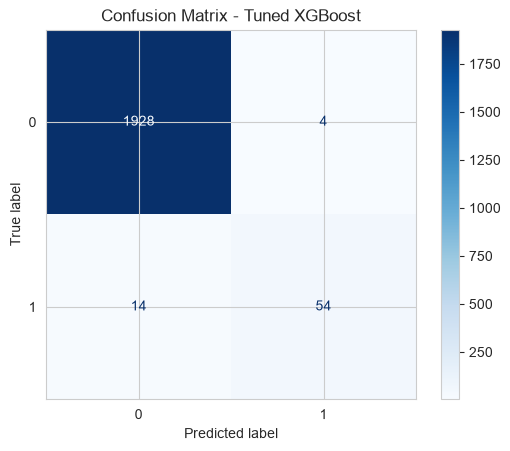

In [216]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_fe,
    y_pred,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

In [217]:
feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    best_model
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
5,num__Rotational speed [rpm],0.211103
10,num__Overstrain,0.204398
9,num__Power,0.178108
8,num__Heat Dissipation,0.098914
7,num__Tool wear [min],0.088121
6,num__Torque [Nm],0.060260
1,cat__Type_L,0.058723
2,cat__Type_M,0.034936
3,num__Air temperature [K],0.023984
4,num__Process temperature [K],0.022488


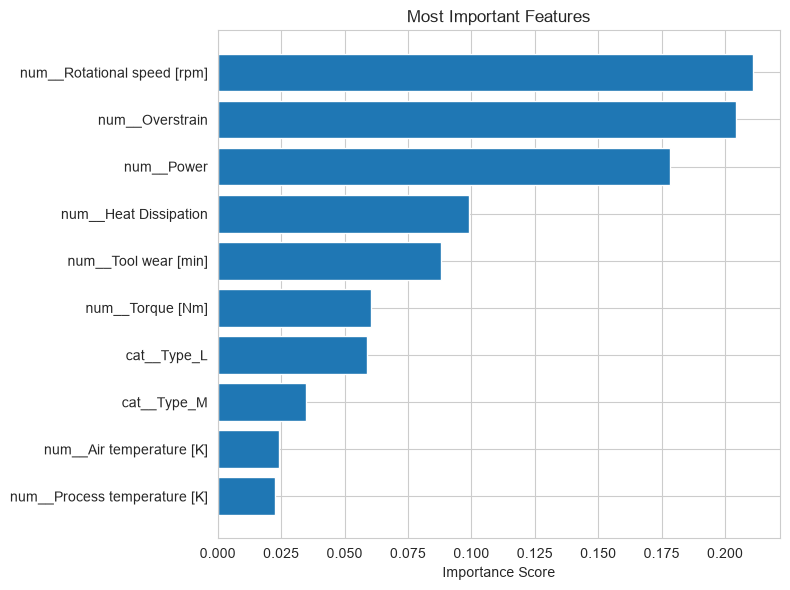

In [218]:
plt.figure(figsize=(8, 6))

plt.barh(
    importance_df["Feature"].head(10),
    importance_df["Importance"].head(10)
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.title("Most Important Features")

plt.tight_layout()
plt.show()

In [219]:
import joblib

joblib.dump(
    best_model,
    "xgboost_predictive_maintenance.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [220]:
model = joblib.load(
    "xgboost_predictive_maintenance.pkl"
)



In [221]:
y_pred_xgb = model.predict(X_test_fe)

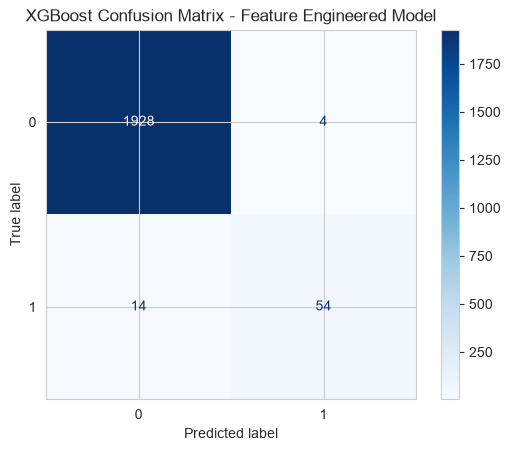

In [222]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_fe,
    y_pred_xgb,
    cmap="Blues",
    values_format="d"
)

plt.title("XGBoost Confusion Matrix - Feature Engineered Model")
plt.show()

In [223]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    y_test_fe,
    y_pred_xgb
).ravel()

error_analysis = pd.DataFrame({
    "Error Type": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Count": [
        tn,
        fp,
        fn,
        tp
    ],
    "Operational Meaning": [
        "Healthy machine correctly identified",
        "Healthy machine incorrectly flagged for maintenance",
        "Failing machine incorrectly classified as healthy",
        "Failing machine correctly identified"
    ]
})

error_analysis

,Error Type,Count,Operational Meaning
0,True Negatives,1928,Healthy machine correctly identified
1,False Positives,4,Healthy machine incorrectly flagged for mainte...
2,False Negatives,14,Failing machine incorrectly classified as healthy
3,True Positives,54,Failing machine correctly identified


In [224]:
print("XGBoost Error Analysis")
print("----------------------")

print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")

print("\nFalse Negative Rate:",
      round(fn / (fn + tp), 3))

print("False Positive Rate:",
      round(fp / (fp + tn), 3))

XGBoost Error Analysis
----------------------
True Negatives  : 1928
False Positives : 4
False Negatives : 14
True Positives  : 54

False Negative Rate: 0.206
False Positive Rate: 0.002


# classification report

In [225]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_fe,
        y_pred_xgb,
        target_names=[
            "No Failure",
            "Machine Failure"
        ],
        zero_division=0
    )
)

                 precision    recall  f1-score   support

     No Failure       0.99      1.00      1.00      1932
Machine Failure       0.93      0.79      0.86        68

       accuracy                           0.99      2000
      macro avg       0.96      0.90      0.93      2000
   weighted avg       0.99      0.99      0.99      2000

